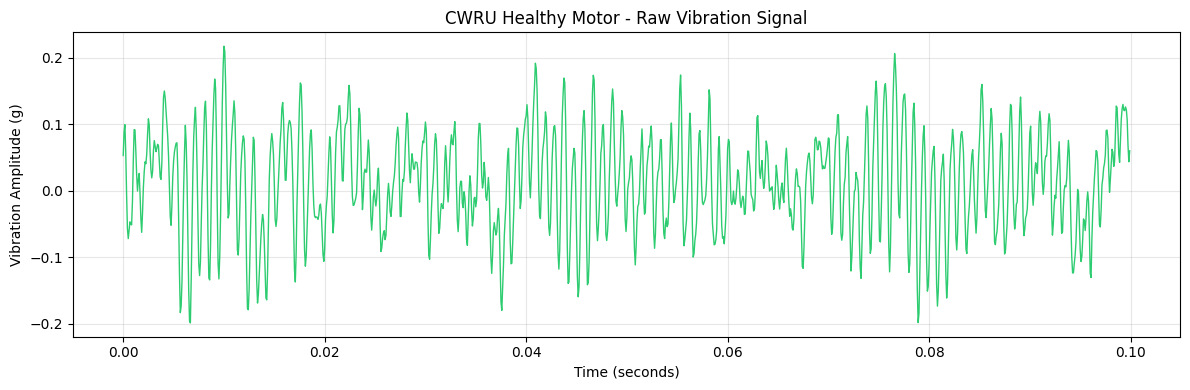

Success! Loaded 243938 samples.


In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Target the first normal motor file
file_path = Path('../data/raw/normal/97.mat')

if not file_path.exists():
    print("Error: File not found. The path might be slightly off.")
else:
    # Load the MATLAB file
    mat = scipy.io.loadmat(str(file_path))
    
    # Extract the drive-end vibration signal (ignoring metadata keys)
    data_keys = [k for k in mat.keys() if not k.startswith('_')]
    signal = mat[data_keys[0]].flatten()
    
    # Create time array for 0.1 seconds (1200 samples at 12kHz)
    t = np.arange(1200) / 12000
    
    # Plot the signal
    plt.figure(figsize=(12, 4))
    plt.plot(t, signal[:1200], color='#2ecc71', linewidth=1)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Vibration Amplitude (g)')
    plt.title('CWRU Healthy Motor - Raw Vibration Signal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the figure to your reports folder
    plt.savefig('../reports/figures/day1_healthy_signal.png', dpi=150)
    plt.show()
    
    print(f"Success! Loaded {len(signal)} samples.")

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from src.data_loader import CWRUDataLoader

# Load all data
loader = CWRUDataLoader()
df = loader.load_dataset('../data/raw/', verbose=True)

print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst 3 rows (metadata only):")
print(df[['window_id', 'fault_type', 'severity', 'load_hp', 'source_file']].head(3))

  Loading: 100.mat [normal, 0.0", 0HP] → 236 windows
  Loading: 97.mat [normal, 0.0", 1HP] → 118 windows
  Loading: 98.mat [normal, 0.0", 2HP] → 235 windows
  Loading: 99.mat [normal, 0.0", 3HP] → 235 windows
  Loading: 105.mat [inner_race, 0.007", 0HP] → 58 windows
  Loading: 106.mat [inner_race, 0.007", 1HP] → 58 windows
  Loading: 107.mat [inner_race, 0.007", 2HP] → 58 windows
  Loading: 108.mat [inner_race, 0.007", 3HP] → 59 windows
  Loading: 169.mat [inner_race, 0.014", 0HP] → 58 windows
  Loading: 170.mat [inner_race, 0.014", 1HP] → 58 windows
  Loading: 171.mat [inner_race, 0.014", 2HP] → 58 windows
  Loading: 172.mat [inner_race, 0.014", 3HP] → 58 windows
  Loading: 209.mat [inner_race, 0.021", 0HP] → 58 windows
  Loading: 210.mat [inner_race, 0.021", 1HP] → 58 windows
  Loading: 211.mat [inner_race, 0.021", 2HP] → 58 windows
  Loading: 212.mat [inner_race, 0.021", 3HP] → 58 windows
  Loading: 130.mat [outer_race, 0.007", 0HP] → 58 windows
  Loading: 131.mat [outer_race, 0.007

normal          | RMS: 0.06664 | Peak: 0.22530 | Mean: 0.012454
inner_race      | RMS: 0.28596 | Peak: 1.48271 | Mean: 0.015576
outer_race      | RMS: 0.68004 | Peak: 3.54758 | Mean: 0.034215
ball            | RMS: 0.13722 | Peak: 0.50907 | Mean: 0.015515


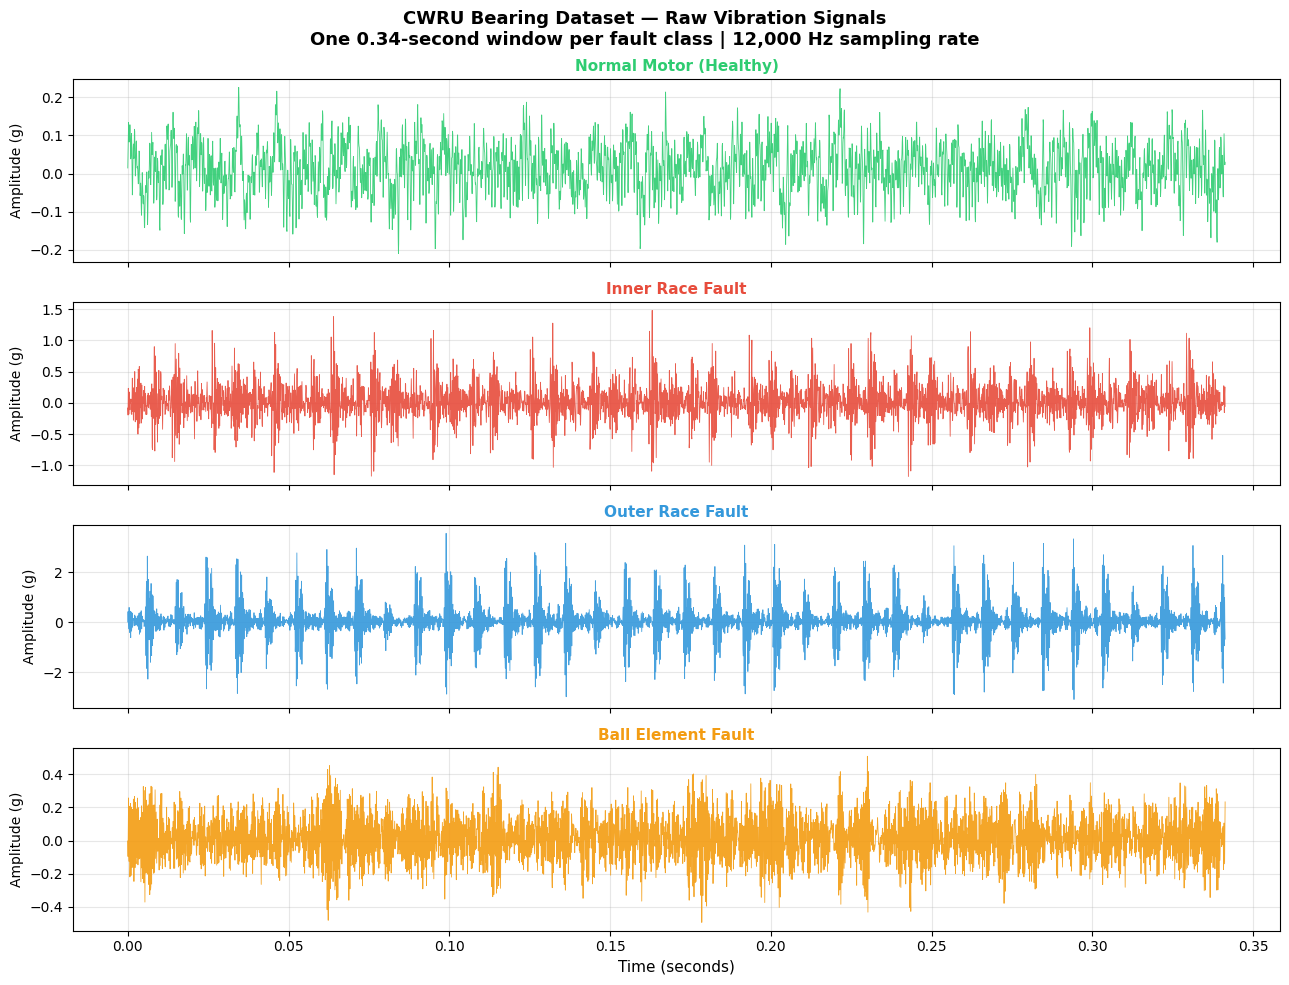


Figure saved.


In [2]:
# Colors for each fault type
COLORS = {
    'normal':      '#2ecc71',   # green  — healthy
    'inner_race':  '#e74c3c',   # red    — inner race fault
    'outer_race':  '#3498db',   # blue   — outer race fault
    'ball':        '#f39c12'    # orange — ball fault
}

TITLES = {
    'normal':      'Normal Motor (Healthy)',
    'inner_race':  'Inner Race Fault',
    'outer_race':  'Outer Race Fault',
    'ball':        'Ball Element Fault'
}

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for ax, fault_type in zip(axes, COLORS.keys()):
    # Get one window from this fault class
    sample = df[df['fault_type'] == fault_type]['signal'].iloc[0]
    
    # Time axis: 4096 samples at 12kHz = 0.341 seconds
    t = np.arange(len(sample)) / 12000
    
    ax.plot(t, sample, color=COLORS[fault_type], linewidth=0.6, alpha=0.9)
    ax.set_ylabel('Amplitude (g)', fontsize=10)
    ax.set_title(TITLES[fault_type], fontsize=11, fontweight='bold', color=COLORS[fault_type])
    ax.grid(True, alpha=0.3)
    
    # Print basic stats for each class
    print(f"{fault_type:15s} | RMS: {np.sqrt(np.mean(sample**2)):.5f} | Peak: {np.max(np.abs(sample)):.5f} | Mean: {sample.mean():.6f}")

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
fig.suptitle(
    'CWRU Bearing Dataset — Raw Vibration Signals\n'
    'One 0.34-second window per fault class | 12,000 Hz sampling rate',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day2_four_class_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved.")

In [2]:
import os
from pathlib import Path

print("Current folder:", os.getcwd())

target_dir = Path('../data/raw/normal/')
if target_dir.exists():
    print(f"Inside {target_dir}:", os.listdir(target_dir))
else:
    print(f"Error: The folder {target_dir} does not seem to exist relative to this notebook.")

Current folder: C:\Users\Avalokiteshwar Yadav\Desktop\motor-health-intelligence-system\notebooks
Inside ..\data\raw\normal: []


In [3]:
# How many windows per severity level?
print("Windows per fault type and severity:")
print(df.groupby(['fault_type', 'severity'])['window_id'].count())

print("\n" + "─"*50)

# What does one window look like?
sample_row = df[df['fault_type'] == 'inner_race'].iloc[0]
print(f"\nExample inner_race window:")
print(f"  window_id : {sample_row['window_id']}")
print(f"  fault_type: {sample_row['fault_type']}")
print(f"  severity  : {sample_row['severity']} inches")
print(f"  load_hp   : {sample_row['load_hp']} HP")
print(f"  label     : {sample_row['label']}")
print(f"  signal    : numpy array, shape {sample_row['signal'].shape}")
print(f"  signal[0] : {sample_row['signal'][0]:.6f}")

print("\n" + "─"*50)

# Severity distribution — how many examples per severity level?
print("\nSeverity distribution (for fault classes only):")
fault_df = df[df['fault_type'] != 'normal']
print(fault_df.groupby(['fault_type', 'severity'])['window_id']
      .count().to_string())

Windows per fault type and severity:
fault_type  severity
ball        0.007       232
            0.014       232
inner_race  0.007       233
            0.014       232
            0.021       232
normal      0.000       824
outer_race  0.007       174
            0.014       174
Name: window_id, dtype: int64

──────────────────────────────────────────────────

Example inner_race window:
  window_id : 824
  fault_type: inner_race
  severity  : 0.007 inches
  load_hp   : 0 HP
  label     : 1
  signal    : numpy array, shape (4096,)
  signal[0] : -0.083004

──────────────────────────────────────────────────

Severity distribution (for fault classes only):
fault_type  severity
ball        0.007       232
            0.014       232
inner_race  0.007       233
            0.014       232
            0.021       232
outer_race  0.007       174
            0.014       174
